# Neural Mesh Implementation

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

In [ ]:
# For reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


In [ ]:
# Neural Mesh
class ResolutionLayer(nn.Module):
    """
    Eq. (2)-(4)

    Centers parameterised as base value + cumulative softplus gaps
    Eq. (23)
    """
    def __init__(self, num_neurons: int, domain_min: float, domain_max: float):
        """
        Args:
            num_neurons: Number of tent neurons R in this layer.
            domain_min:  Left end of the input domain.
            domain_max:  Right end of the input domain.

        Initialises the centres uniformly between domain_min and domain_max,
        then converts them into the parameterisation
            g_0 = first centre
            g_r = g_0 + sum_{k<r} (softplus(delta_k) + eps)
        so that the initial gaps reproduce the uniform linspace exactly.
        """
        super().__init__()
        self.num_neurons = num_neurons
        self.eps = 1e-4

        init_centres = torch.linspace(domain_min, domain_max, num_neurons)
        self.g0 = nn.Parameter(init_centres[0:1])  # base value, shape (1,)

        if num_neurons > 1:
            init_gaps = init_centres[1:] - init_centres[:-1]
            # invert softplus so initial centers reproduce the linspace exactly
            init_gaps = torch.clamp(init_gaps - self.eps, min=1e-6)
            init_delta = torch.log(torch.expm1(init_gaps))
            self.delta_raw = nn.Parameter(init_delta)  # shape (num_neurons - 1,)
        else:
            self.delta_raw = None

    def centers(self) -> torch.Tensor:
        """
        Compute the tent centres from the unconstrained parameters.

        Returns:
            Tensor of shape (num_neurons,) containing the centres g,
            guaranteed to be strictly ascending because each gap is
            softplus(delta_raw) + eps > 0.
        """
        if self.num_neurons == 1:
            return self.g0
        gaps = F.softplus(self.delta_raw) + self.eps          # (N-1,), always > 0
        return torch.cat([self.g0, self.g0 + torch.cumsum(gaps, dim=0)])

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: Tensor of shape (batch, 1) containing scalar inputs.

        Returns:
            Tensor of shape (batch, num_neurons) whose entries are the
            tent activations. Each row is non-negative and sums to 1.
            Outside the outermost centres, the nearest boundary neuron
            saturates at 1 and all others are 0.
        """
        # x: (batch, 1)
        batch_size = x.size(0)
        if self.num_neurons == 1:
            return torch.ones(batch_size, 1, device=x.device)

        g = self.centers()                     # (num_neurons,), strictly ascending
        g_exp = g.unsqueeze(0)                 # (1, num_neurons)

        g_left = g_exp[:, :-1]                 # (1, N-1)
        g_right = g_exp[:, 1:]                 # (1, N-1)
        denom = g_right - g_left               # always > eps by construction

        left_slope = (x - g_left) / denom      # (batch, N-1)
        right_slope = (g_right - x) / denom    # (batch, N-1)

        # Boundary neurons
        w_left = torch.clamp(right_slope[:, 0], 0.0, 1.0).unsqueeze(1)    # neuron 0
        w_right = torch.clamp(left_slope[:, -1], 0.0, 1.0).unsqueeze(1)   # neuron N-1

        # Interior neurons (1 .. N-2)
        if self.num_neurons == 2:
            weights = torch.cat([w_left, w_right], dim=1)
        else:
            interior = torch.min(left_slope[:, :-1], right_slope[:, 1:])
            interior = torch.clamp(interior, 0.0, 1.0)       # (batch, N-2)
            weights = torch.cat([w_left, interior, w_right], dim=1)

        return weights


class ComplexityLayer(nn.Module):
    """
    Eq. (7)-(9)
    """
    def __init__(self, resolution_neurons: int, complexity_neurons: int):
        """
        Args:
            resolution_neurons: Number of input neurons R from the Resolution Layer.
            complexity_neurons: Number of output neurons C for this input,
                i.e. the rank of the representation along this dimension.
        """
        super().__init__()
        # U is (R, C). We want each ROW to sum to 1 (SNNN condition).
        self.U_raw = nn.Parameter(torch.randn(resolution_neurons, complexity_neurons))

    def forward(self, s: torch.Tensor) -> torch.Tensor:
        """
        Args:
            s: Tensor of shape (batch, R) containing the Resolution Layer
               outputs for one input dimension. Each row sums to 1.

        Returns:
            Tensor of shape (batch, C) containing the complexity functions
            f^C(x). Each row is non-negative and sums to 1, because the
            row-stochastic U preserves the sum-to-one property.
        """
        # Softmax over dim=1 (columns) makes each row sum to 1
        U_norm = F.softmax(self.U_raw, dim=1)  # Shape: (R, C)
        # Now f = s @ U_norm. Since s sums to 1, f sums to 1.
        return torch.matmul(s, U_norm)


class CoreMesh(nn.Module):
    """
    Eq. (10)
    """
    def forward(self, complexity_outputs: list) -> torch.Tensor:
        """
        Args:
            complexity_outputs: List of N tensors, each of shape
                (batch, C_n), one per input dimension. Each row sums to 1.

        Returns:
            - If N == 1, returns the single complexity tensor unchanged,
              shape (batch, C_1).
            - If N >= 2, returns a tensor of shape (batch, C_1, ..., C_N)
              containing the mesh weights, which are non-negative and sum
              to 1 over all vertex indices.
        """
        # If there is only 1 input, just return its Complexity output (no multiplication)
        if len(complexity_outputs) == 1:
            return complexity_outputs[0]

        # Start with the first input's complexity vector: (batch_size, C_1)
        mesh = complexity_outputs[0]

        # Sequentially multiply by the remaining complexity vectors
        for f in complexity_outputs[1:]:
            spatial_dims = mesh.dim() - 1
            f_expanded = f.view(f.shape[0], *([1] * spatial_dims), f.shape[1])
            mesh = mesh.unsqueeze(-1) * f_expanded

        return mesh


class OutputLayer(nn.Module):
    """
    Eq. (5)-(6)
    Output layer that keeps the map affine in the control input u, matching
    the classical TS/TP plant form used in PDC/LMI controller synthesis:

        x_{k+1} = sum_i w_i(x) * (A_i x + B_i u)

    Each mesh vertex i = (c1, ..., cN) gets its own local affine model
    (A_i, B_i)
    """
    def __init__(self, mesh_shape: tuple, state_dim: int, u_dim: int, output_dim: int):
        """
        Args:
            mesh_shape:  Tuple (C_1, ..., C_N) giving the number of vertices
                along each mesh dimension.
            state_dim:   Dimension of the scheduling state x used by A_i.
            u_dim:       Dimension of the control input u used by B_i.
            output_dim:  Dimension of the output (e.g. 2 for [theta, theta_dot]).
        """
        super().__init__()
        self.mesh_shape = mesh_shape
        self.state_dim = state_dim
        self.u_dim = u_dim
        self.output_dim = output_dim
        # A: (C_1, ..., C_N, output_dim, state_dim)  -- per-vertex state matrices
        self.A = nn.Parameter(torch.randn(*mesh_shape, output_dim, state_dim) * 0.1)
        # B: (C_1, ..., C_N, output_dim, u_dim)       -- per-vertex input matrices
        self.B = nn.Parameter(torch.randn(*mesh_shape, output_dim, u_dim) * 0.1)

    def forward(self, mesh: torch.Tensor, x_state: torch.Tensor, u: torch.Tensor) -> torch.Tensor:
        """
        Args:
            mesh:    (batch, C_1, ..., C_N)  vertex weights w_i(x), sum to 1 (SNNN)
            x_state: (batch, state_dim)
            u:       (batch, u_dim)
        Returns:
            (batch, output_dim)
        """
        # Local affine prediction at every vertex: A_i x + B_i u
        # -> (batch, C_1, ..., C_N, output_dim)
        Ax = torch.einsum('...od,bd->b...o', self.A, x_state)
        Bu = torch.einsum('...od,bd->b...o', self.B, u)
        local = Ax + Bu

        # Weight by mesh (broadcast over output_dim) and sum over all vertices
        w = mesh.unsqueeze(-1)                                    # (batch, C_1,...,C_N, 1)
        out = (w * local).sum(dim=tuple(range(1, mesh.dim())))
        return out

    def vertex_matrices(self):
        """Convenience accessor for PDC/LMI tooling: returns (A, B) as plain
        tensors of shape (C_1,...,C_N, output_dim, state_dim/u_dim)."""

        return self.A.detach(), self.B.detach()



class NeuralMesh(nn.Module):
    def __init__(self, state_dims: list, u_dim: int, resolutions: list,
                 complexities: list, output_dim: int):
        """
        Args:
            state_dims: list of (min, max) tuples, one per SCHEDULING (state) input.
            u_dim: dimensionality of the control input (enters affinely, not scheduled).
            resolutions: list of R_n for each state input.
            complexities: list of C_n for each state input.
            output_dim: dimension of the output (e.g. 4 for [x, x_dot, theta, theta_dot]).
        """
        super().__init__()
        self.state_dims = state_dims
        self.u_dim = u_dim
        self.resolutions = resolutions
        self.complexities = complexities
        self.output_dim = output_dim
        self.num_states = len(state_dims)

        self.resolution_layers = nn.ModuleList([
            ResolutionLayer(R, min_val, max_val)
            for (min_val, max_val), R in zip(state_dims, resolutions)
        ])
        self.complexity_layers = nn.ModuleList([
            ComplexityLayer(R, C)
            for R, C in zip(resolutions, complexities)
        ])
        self.core_mesh = CoreMesh()
        self.output_layer = OutputLayer(
            tuple(complexities), self.num_states, u_dim, output_dim
        )

    def forward(self, x_state: torch.Tensor, u: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x_state: (batch, num_states) -- scheduling variables only
            u: (batch, u_dim) -- control input, enters affinely
        Returns:
            (batch, output_dim)
        """
        s_list = [layer(x_state[:, i:i + 1]) for i, layer in enumerate(self.resolution_layers)]
        f_list = [layer(s) for layer, s in zip(self.complexity_layers, s_list)]
        mesh = self.core_mesh(f_list)                # (batch, C_1, ..., C_N)
        return self.output_layer(mesh, x_state, u)

    def get_config(self) -> dict:
        return {
            "state_dims": self.state_dims,
            "u_dim": self.u_dim,
            "resolutions": self.resolutions,
            "complexities": self.complexities,
            "output_dim": self.output_dim,
        }


def save_checkpoint(model: NeuralMesh, path: str):
    torch.save({"config": model.get_config(), "state_dict": model.state_dict()}, path)


def load_checkpoint(path: str, map_location=None) -> NeuralMesh:
    ckpt = torch.load(path, map_location=map_location)
    model = NeuralMesh(**ckpt["config"])
    model.load_state_dict(ckpt["state_dict"])
    return model

# Simple Pendulum

The simple pendulum example is a non-linear system. The Neural Mesh approximates the nonlinear pendulum as a weighted blend of local linear models:
$$x_{k+1} = \sum_{i=1}^{r} w_i(\theta, \dot{\theta})\,(A_i x_k + B_i u_k)$$
This is a discrete-time TS model.

In [ ]:
# Simulation parameters
dt = 0.02
num_steps = 100
num_trajectories = 2000
total_samples = num_trajectories * num_steps

# Pendulum parameters
m, l, g, b = 1.0, 1.0, 9.81, 0.1     # mass, length, gravity, damping

def pendulum_dynamics(state, u):
    theta, theta_dot = state
    theta_ddot = (g/l)*np.sin(theta) - (b/(m*l*l))*theta_dot + u/(m*l*l) # non-linear
    return np.array([theta_dot, theta_ddot])

theta_limits     = (-np.pi, np.pi)
theta_dot_limits = (-5.0, 5.0)
u_limits         = (-10.0, 10.0)

X_data = np.zeros((total_samples, 3))    # [theta, theta_dot, u]
Y_data = np.zeros((total_samples, 2))    # [next_theta, next_theta_dot]

idx = 0
for traj in range(num_trajectories):
    state = np.array([np.random.uniform(*theta_limits),
                      np.random.uniform(*theta_dot_limits)])
    for step in range(num_steps):
        # 0.5 small stabilizing-scale torque, 0.5 broad exploration
        if np.random.rand() < 0.5:
            u = np.random.uniform(-2.0, 2.0)
        else:
            u = np.random.uniform(*u_limits)
        X_data[idx, :2] = state
        X_data[idx, 2]  = u
        Y_data[idx]     = state + dt * pendulum_dynamics(state, u)
        state           = Y_data[idx]
        idx += 1

print(f"Generated {idx} samples.")

# Neural Mesh parameters
state_dims   = [(-np.pi, np.pi),   # theta
                (-5.0, 5.0)]       # theta_dot
u_dim        = 1
resolutions  = [11, 9]             # more resolution on theta
complexities = [2, 2]              # 4 vertices
output_dim   = 2

model = NeuralMesh(state_dims, u_dim, resolutions, complexities, output_dim).to(device)

# Split X_data into state and control once, up front.
X_state_data = X_data[:, :2]
U_data       = X_data[:, 2:3]

# Convert data to tensors, move to device
X_state_t = torch.tensor(X_state_data, dtype=torch.float32, device=device)
U_t = torch.tensor(U_data, dtype=torch.float32, device=device)
Y_t = torch.tensor(Y_data, dtype=torch.float32, device=device)

Generated 200000 samples.


In [ ]:
# Training loop
# Split data
split_idx = int(0.8 * len(X_state_t))
Xs_train, Xs_val = X_state_t[:split_idx], X_state_t[split_idx:]
U_train, U_val = U_t[:split_idx], U_t[split_idx:]
Y_train, Y_val = Y_t[:split_idx], Y_t[split_idx:]

train_loader = DataLoader(TensorDataset(Xs_train, U_train, Y_train), batch_size=256, shuffle=True)
val_loader = DataLoader(TensorDataset(Xs_val, U_val, Y_val), batch_size=256, shuffle=False)

# Early stopping setup
best_val_loss = float('inf')
patience = 15          # stop if no improvement for 15 epochs
wait = 0

loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(300):
    # --- Training ---
    model.train()
    train_loss = 0.0
    for xb, ub, yb in train_loader:
        pred = model(xb, ub)
        loss = loss_fn(pred, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    # --- Validation ---
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, ub, yb in val_loader:
            pred = model(xb, ub)
            val_loss += loss_fn(pred, yb).item()
    val_loss /= len(val_loader)

    if epoch % 1 == 0:
        print(f"Epoch {epoch}: Train {train_loss:.4f}, Val {val_loss:.4f}")

    # --- Early stopping check ---
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        wait = 0
        save_checkpoint(model, "best_model.pth")  # save the best one
    else:
        wait += 1
        if wait >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

Epoch 0: Train 5.2992, Val 1.7480
Epoch 1: Train 0.6099, Val 0.0997
Epoch 2: Train 0.0364, Val 0.0192
Epoch 3: Train 0.0148, Val 0.0130
Epoch 4: Train 0.0112, Val 0.0105
Epoch 5: Train 0.0096, Val 0.0095
Epoch 6: Train 0.0089, Val 0.0090
Epoch 7: Train 0.0086, Val 0.0087
Epoch 8: Train 0.0084, Val 0.0086
Epoch 9: Train 0.0083, Val 0.0085
Epoch 10: Train 0.0082, Val 0.0085
Epoch 11: Train 0.0082, Val 0.0085
Epoch 12: Train 0.0082, Val 0.0085
Epoch 13: Train 0.0082, Val 0.0085
Epoch 14: Train 0.0082, Val 0.0084
Epoch 15: Train 0.0081, Val 0.0083
Epoch 16: Train 0.0078, Val 0.0075
Epoch 17: Train 0.0061, Val 0.0037
Epoch 18: Train 0.0032, Val 0.0030
Epoch 19: Train 0.0029, Val 0.0029
Epoch 20: Train 0.0028, Val 0.0028
Epoch 21: Train 0.0028, Val 0.0028
Epoch 22: Train 0.0027, Val 0.0027
Epoch 23: Train 0.0027, Val 0.0027
Epoch 24: Train 0.0027, Val 0.0027
Epoch 25: Train 0.0027, Val 0.0027
Epoch 26: Train 0.0027, Val 0.0027
Epoch 27: Train 0.0027, Val 0.0027
Epoch 28: Train 0.0027, Val 0.

In [ ]:
# Test trajectory
model = load_checkpoint("best_model.pth", map_location=torch.device('cpu'))
model.to(device)
model.eval()

NeuralMesh(
  (resolution_layers): ModuleList(
    (0-1): 2 x ResolutionLayer()
  )
  (complexity_layers): ModuleList(
    (0-1): 2 x ComplexityLayer()
  )
  (core_mesh): CoreMesh()
  (output_layer): OutputLayer()
)

In [ ]:
# Open Loop Accuracy (held-out validation set)

# Reports MSE and normalized RMSE (NRMSE, relative to each output's data range)
# on the held-out validation split, per output dimension and overall.

with torch.no_grad():
    val_pred = model(Xs_val, U_val)
    per_dim_se = (val_pred - Y_val) ** 2                     # (N_val, output_dim)
    mse_per_dim = per_dim_se.mean(dim=0).cpu().numpy()       # (output_dim,)
    mse_overall = per_dim_se.mean().item()

    rmse_per_dim = np.sqrt(mse_per_dim)
    y_val_np = Y_val.cpu().numpy()
    data_range = y_val_np.max(axis=0) - y_val_np.min(axis=0)  # (output_dim,)
    nrmse_per_dim = rmse_per_dim / np.where(data_range > 0, data_range, 1.0)

output_labels = ['theta', 'theta_dot']
print("[open-loop check] held-out validation accuracy (one-step prediction on Euler-discretized data):")
print(f"  Overall MSE: {mse_overall:.6f}")
for lbl, mse_i, rmse_i, nrmse_i in zip(output_labels, mse_per_dim, rmse_per_dim, nrmse_per_dim):
    print(f"  {lbl:>10s}: MSE={mse_i:.6f}  RMSE={rmse_i:.6f}  NRMSE={nrmse_i*100:.2f}% of data range")


[open-loop check] held-out validation accuracy (one-step prediction):
  Overall MSE: 0.002594
       theta: MSE=0.000000  RMSE=0.000061  NRMSE=0.00% of data range
   theta_dot: MSE=0.005188  RMSE=0.072029  NRMSE=0.45% of data range


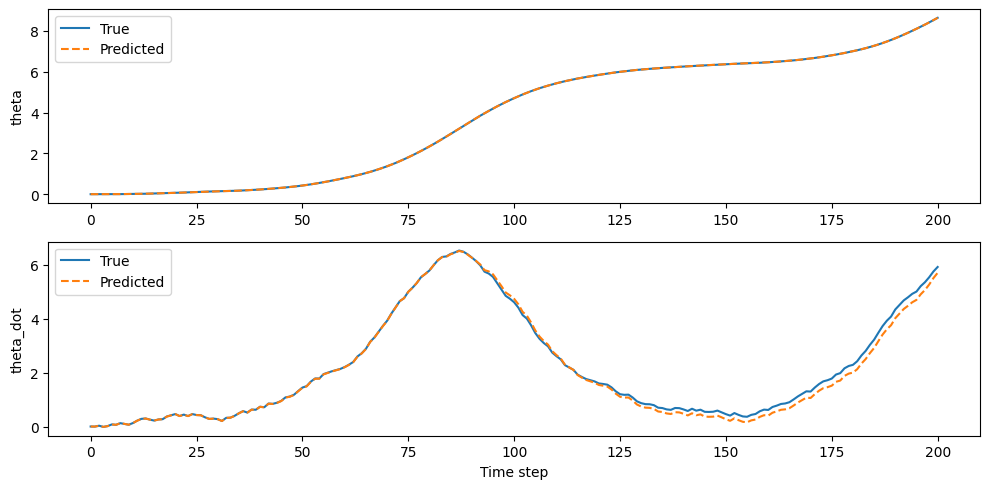

In [ ]:
state = np.array([0.0, 0.0])                       # [theta, theta_dot]
u_seq = np.random.uniform(-5, 5, 200)

true_states = [state]
pred_states = [state]

with torch.no_grad():
    for u in u_seq:
        # True dynamics (analytic pendulum, not pendsim)
        next_true = state + dt * pendulum_dynamics(state, u)
        true_states.append(next_true)

        # Neural Mesh prediction
        state_t = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
        u_t     = torch.tensor([u],   dtype=torch.float32, device=device).unsqueeze(0)
        pred_next = model(state_t, u_t).cpu().numpy().squeeze()
        pred_states.append(pred_next)

        state = next_true

true_states = np.array(true_states)
pred_states = np.array(pred_states)

# --- Plot ---
fig, axs = plt.subplots(2, 1, figsize=(10, 5))
labels = ['theta', 'theta_dot']
for i, ax in enumerate(axs):
    ax.plot(true_states[:, i], label='True')
    ax.plot(pred_states[:, i], '--', label='Predicted')
    ax.set_ylabel(labels[i])
    ax.legend()
plt.xlabel('Time step')
plt.tight_layout()
plt.show()

In [ ]:
# Extract the PDC-ready vertex matrices
# A: (C1, C2, output_dim, state_dim) -- per-vertex state matrices, shape (2,2,2,2)
# B: (C1, C2, output_dim, u_dim)     -- per-vertex input matrices, shape (2,2,2,1)
A_tensor, B_tensor = model.output_layer.vertex_matrices()

def to_np(t):
    if hasattr(t, "detach"):
        return t.detach().cpu().numpy().astype(np.float64)
    return np.asarray(t, dtype=np.float64)

def mesh_weights(model, state):
    with torch.no_grad():
        x = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
        s = [L(x[:, i:i+1]) for i, L in enumerate(model.resolution_layers)]
        f = [L(si) for L, si in zip(model.complexity_layers, s)]
        mesh = model.core_mesh(f)
    return mesh.squeeze(0).cpu().numpy().reshape(-1)

In [ ]:
# SNNN / Convexity Check

# (Eq. (19)) is that convexity is guaranteed by
# construction throughout training: the mesh firing strengths w_i(x) must be
# non-negative and sum to 1 for every x in the domain
# Verified numerically by sampling a few thousand random points across the full
# trained domain and checking both properties directly.
n_check = 5000
theta_samples = np.random.uniform(*theta_limits, n_check)
theta_dot_samples = np.random.uniform(*theta_dot_limits, n_check)

min_weight = np.inf
max_sum_dev = 0.0
sum_devs = np.zeros(n_check)

for i in range(n_check):
    x_sample = np.array([theta_samples[i], theta_dot_samples[i]])
    w = mesh_weights(model, x_sample)
    min_weight = min(min_weight, w.min())
    dev = abs(w.sum() - 1.0)
    sum_devs[i] = dev
    max_sum_dev = max(max_sum_dev, dev)

print(f"\n[SNNN / convexity check] {n_check} random points sampled across the full domain:")
print(f"  min mesh weight over all points/vertices: {min_weight:.3e}  (>= 0 required)")
print(f"  max |sum(weights) - 1| over all points:    {max_sum_dev:.3e}")
print(f"  mean |sum(weights) - 1| over all points:   {sum_devs.mean():.3e}")
tol = 1e-4
if min_weight >= -1e-6 and max_sum_dev < tol:
    print("  PASS: mesh firing strengths are non-negative and sum to 1 (SNNN holds).")
else:
    print("  FAIL: SNNN violated -- convexity guarantee does not hold numerically.")


[SNNN / convexity check] 5000 random points sampled across the full domain:
  min mesh weight over all points/vertices: 6.572e-03  (>= 0 required)
  max |sum(weights) - 1| over all points:    2.384e-07
  mean |sum(weights) - 1| over all points:   4.736e-08
  PASS: mesh firing strengths are non-negative and sum to 1 (SNNN holds).
        Model output is therefore guaranteed to lie in the vertex convex hull.


In [ ]:
A_tensor, B_tensor = model.output_layer.vertex_matrices()
A_np, B_np = to_np(A_tensor), to_np(B_tensor)
A_flat = A_np.reshape(-1, *A_np.shape[-2:])   # (r, 2, 2)
B_flat = B_np.reshape(-1, *B_np.shape[-2:])   # (r, 2, 1)
r = A_flat.shape[0]

# --- compute analytic linearization at origin ---
A0 = np.eye(2) + np.array([[0.0, 1.0],
                           [g/l, -b/(m*l*l)]]) * dt
B0 = np.array([[0.0],
               [dt/(m*l*l)]])

# --- compute effective A, B at origin ---
w0 = mesh_weights(model, np.array([0.0, 0.0]))
A_eff = sum(w0[i] * A_flat[i] for i in range(r))
B_eff = sum(w0[i] * B_flat[i] for i in range(r))

# --- sanity check ---
A_err_origin = np.linalg.norm(A0 - A_eff)
B_err_origin = np.linalg.norm(B0 - B_eff)
print(f"Origin error: ||A0-A_eff||={A_err_origin:.4f}, ||B0-B_eff||={B_err_origin:.4f}")

Origin error: ||A0-A_eff||=0.0074, ||B0-B_eff||=0.0003


$F_i$ is the local state-feedback gain matrix for vertex $i$, computed by solving the LMI after training.
<br><br><br><br>
Substituting the control $u_k = -\sum_i w_i(x_k)\, F_i\, x_k$ into the TS model:
$$x_{k+1} = \sum_{i=1}^{r} \sum_{j=1}^{r} w_i(x_k)\, w_j(x_k)\,(A_i - B_i F_j)\, x_k$$

So the closed-loop matrix at any state is:
$$A_{cl}(x) = \sum_{i,j} w_i w_j (A_i - B_i F_j)$$
This is a double convex combination of the pairwise matrices $A_i-B_iF_j$.
<br><br><br><br>
For stability in discrete-time systems $A_{cl}^T P A_{cl} - P \prec 0$ (discrete-time Lyapunov inequality). This should hold for all $A_{cl}$ in the convex hull of  $\{A_i-B_iF_j\}$
This condition is made linear using change of variables. Introduce:
$$X = P^{-1} \succ 0, \qquad M_i = F_i X$$
$X$ is a symmetric positive-definite matrix, and $M_i$ is a matrix of the same shape as $F_iX$. The gain is recovered later as: $M_iX^{-1}$
<br><br><br><br>
Now apply the Schur complement to the Lyapunov inequality. For a single matrix $G$: $$G^T X^{-1} G - X^{-1} \prec 0$$
is equivalent (by Schur complement) to:
$$\begin{bmatrix} X & G^T \\ G & X \end{bmatrix} \succ 0$$
where $G = A_{cl} X = (A_i - B_i F_j) X = A_i X - B_i M_j$
<br><br><br><br>
The standard PDC stability theorem (Tanaka & Wang, 2001) is usually stated as two separate conditions:
**1: Per-vertex conditions**
For each vertex $i$, consider the case where only vertex $i$ is active:
$$G_i = A_i X - B_i M_i$$
The constraint:
$$\begin{bmatrix} X & G_i^T \\ G_i & X \end{bmatrix} \succ 0$$
ensures $A_i-B_iF_i$ is stable.
<br><br>
**2: Pairwise conditions**
For each pair $i\lt j$, consider the case where vertices $i$ and $j$ are both active. The blended closed-loop matrix is:
$$\frac{(A_i - B_i F_j) + (A_j - B_j F_i)}{2}$$

The corresponding $G$ is:
$$G_{ij} = \frac{A_i X - B_i M_j + A_j X - B_j M_i}{2}$$

The constraint:

$$\begin{bmatrix} X & G_{ij}^T \\ G_{ij} & X \end{bmatrix} \succ 0$$
ensures stability when both $i$ and $j$ are active. This covers the case $i=j$ too, but that is already the per-vertex condition.
<br><br><br><br>
**Why per-vertex + pairwise is enough**
if the per-vertex and pairwise conditions hold, then stability holds for all convex combinations of the vertex models. This is because the Lyapunov function
$V(x) = x^T P x = x^T X^{-1} x$ decreases along every possible trajectory, regardless of the weights.

In [ ]:
import cvxpy as cp

n = len(state_dims)              # 2
m = u_dim                        # 1
r = A_flat.shape[0]              # 4
print(f"LMI: n={n}, m={m}, r={r}")

X  = cp.Variable((n, n), symmetric=True)
Ms = [cp.Variable((m, n)) for _ in range(r)]

# X≻ϵI is represented with a tolerance. This keeps the solver away from the boundary and avoids numerical issues.
cons = [X >> 1e-6 * np.eye(n)]

# per-vertex
for i in range(r):
    G = A_flat[i] @ X - B_flat[i] @ Ms[i]
    cons.append(cp.bmat([[X, G.T], [G, X]]) >> 1e-9 * np.eye(2 * n))

# pairwise
for i in range(r):
    for j in range(i + 1, r):
        G = (A_flat[i] @ X - B_flat[i] @ Ms[j]
             + A_flat[j] @ X - B_flat[j] @ Ms[i]) / 2
        cons.append(cp.bmat([[X, G.T], [G, X]]) >> 1e-9 * np.eye(2 * n))

prob = cp.Problem(cp.Minimize(0), cons)
prob.solve(solver=cp.CLARABEL)

print("solver status:", prob.status)
# If the LMI is feasible, a PDC controller exists.
if prob.status in ("optimal", "optimal_inaccurate"):
    Xv = X.value
    Fs = np.stack([Ms[i].value @ np.linalg.inv(Xv) for i in range(r)])
    worst = max(
        np.max(np.abs(np.linalg.eigvals(A_flat[i] - B_flat[i] @ Fs[i])))
        for i in range(r)
    )
    print("worst vertex pole:", worst, "(< 1 necessary)")
    print("gains F_i:\n", Fs.squeeze(1))
else:
    print("LMI infeasible — model needs more training or more vertices")
    Fs = None

LMI: n=2, m=1, r=4
solver status: optimal
worst vertex pole: 0.9891047609864595 (< 1 necessary)
gains F_i:
 [[ 66.5166474   43.02434916]
 [ 26.95427073 106.58442906]
 [ 18.02429518  47.44611143]
 [ 34.56075581  26.01836704]]


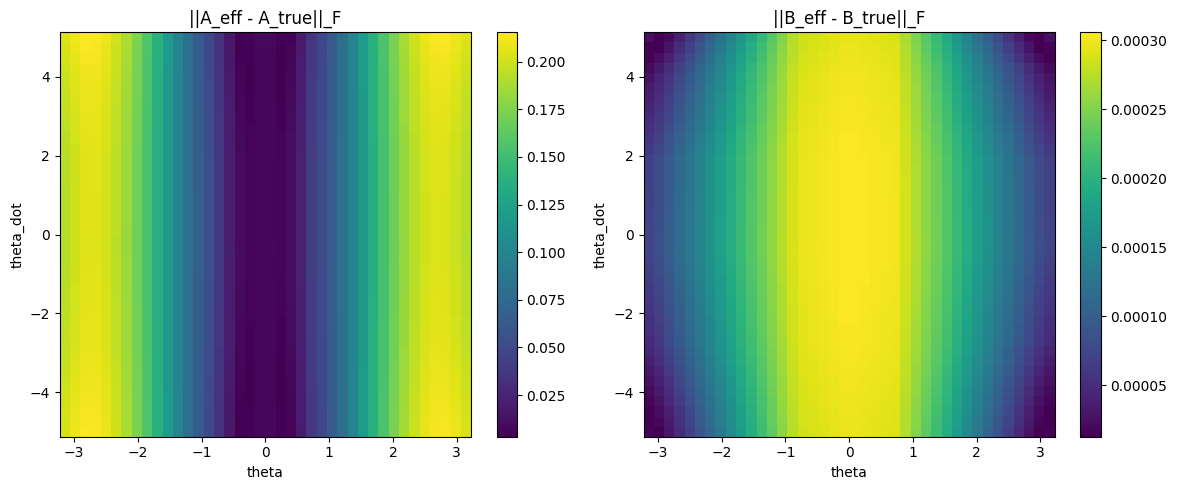

[grid check] max A error: 0.2154, mean A error: 0.1175
[grid check] max B error: 0.0003, mean B error: 0.0002
If errors are small near the training-data-dense region (small theta_dot, moderate theta) but grow near domain edges/corners, that's expected — sparser training coverage there. Large errors *everywhere* would indicate a genuine modelling problem.


In [ ]:
# Grid Based Jacobian Comparision

# The Neural Mesh's "effective" local model at a point x is the convex
# combination of vertex matrices weighted by the mesh firing strengths:
#   A_eff(x) = sum_i w_i(x) A_i,   B_eff(x) = sum_i w_i(x) B_i
# We compare this against the analytically linearized discrete pendulum map
# at the same point, across a grid spanning the full trained domain.

def analytic_AB(theta):
    """Discrete-time Jacobian of the pendulum map at a given theta.
    (Independent of theta_dot and u, since the ODE is linear in both.)"""
    A = np.eye(2) + np.array([[0.0, 1.0],
                               [(g / l) * np.cos(theta), -b / (m * l * l)]]) * dt
    B = np.array([[0.0],
                   [dt / (m * l * l)]])
    return A, B

n_grid = 40
thetas = np.linspace(*theta_limits, n_grid)
theta_dots = np.linspace(*theta_dot_limits, n_grid)

A_err = np.zeros((n_grid, n_grid))
B_err = np.zeros((n_grid, n_grid))

for i, td in enumerate(theta_dots):
    for j, th in enumerate(thetas):
        x = np.array([th, td])
        w = mesh_weights(model, x)                       # (r,)
        A_eff = sum(w[k] * A_flat[k] for k in range(r))
        B_eff = sum(w[k] * B_flat[k] for k in range(r))
        A_true, B_true = analytic_AB(th)
        A_err[i, j] = np.linalg.norm(A_eff - A_true, 'fro')
        B_err[i, j] = np.linalg.norm(B_eff - B_true, 'fro')

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
for ax, err, title in zip(axs, [A_err, B_err], ["||A_eff - A_true||_F", "||B_eff - B_true||_F"]):
    im = ax.pcolormesh(thetas, theta_dots, err, shading='auto', cmap='viridis')
    fig.colorbar(im, ax=ax)
    ax.set_xlabel("theta")
    ax.set_ylabel("theta_dot")
    ax.set_title(title)
plt.tight_layout()
plt.savefig("jacobian_error_heatmap.png", dpi=150)
plt.show()

print(f"[grid check] max A error: {A_err.max():.4f}, mean A error: {A_err.mean():.4f}")
print(f"[grid check] max B error: {B_err.max():.4f}, mean B error: {B_err.mean():.4f}")
print("If errors are small near the training-data-dense region (small theta_dot, "
      "moderate theta) but grow near domain edges/corners, that's expected — "
      "sparser training coverage there. Large errors *everywhere* would indicate "
      "a genuine modelling problem.")


The PDC controller:
$$u_k = -\sum_i w_i(x_k)\, F_i\, x_k$$
blends several linear gains $F_i$ using the same state-dependent weights. Each $F_i$ is designed for one local linear model, and the blending handles the nonlinearity. Therefore, the controller stabilises the pendulum from large angles like where a linear controller would fail.

$F_i$ is a matrix of shape (u_dim x state_dim). Here $u$ is scalar torque and the state is $(\theta, \dot{\theta})$. Resulting in a shape of $(1\times2)$

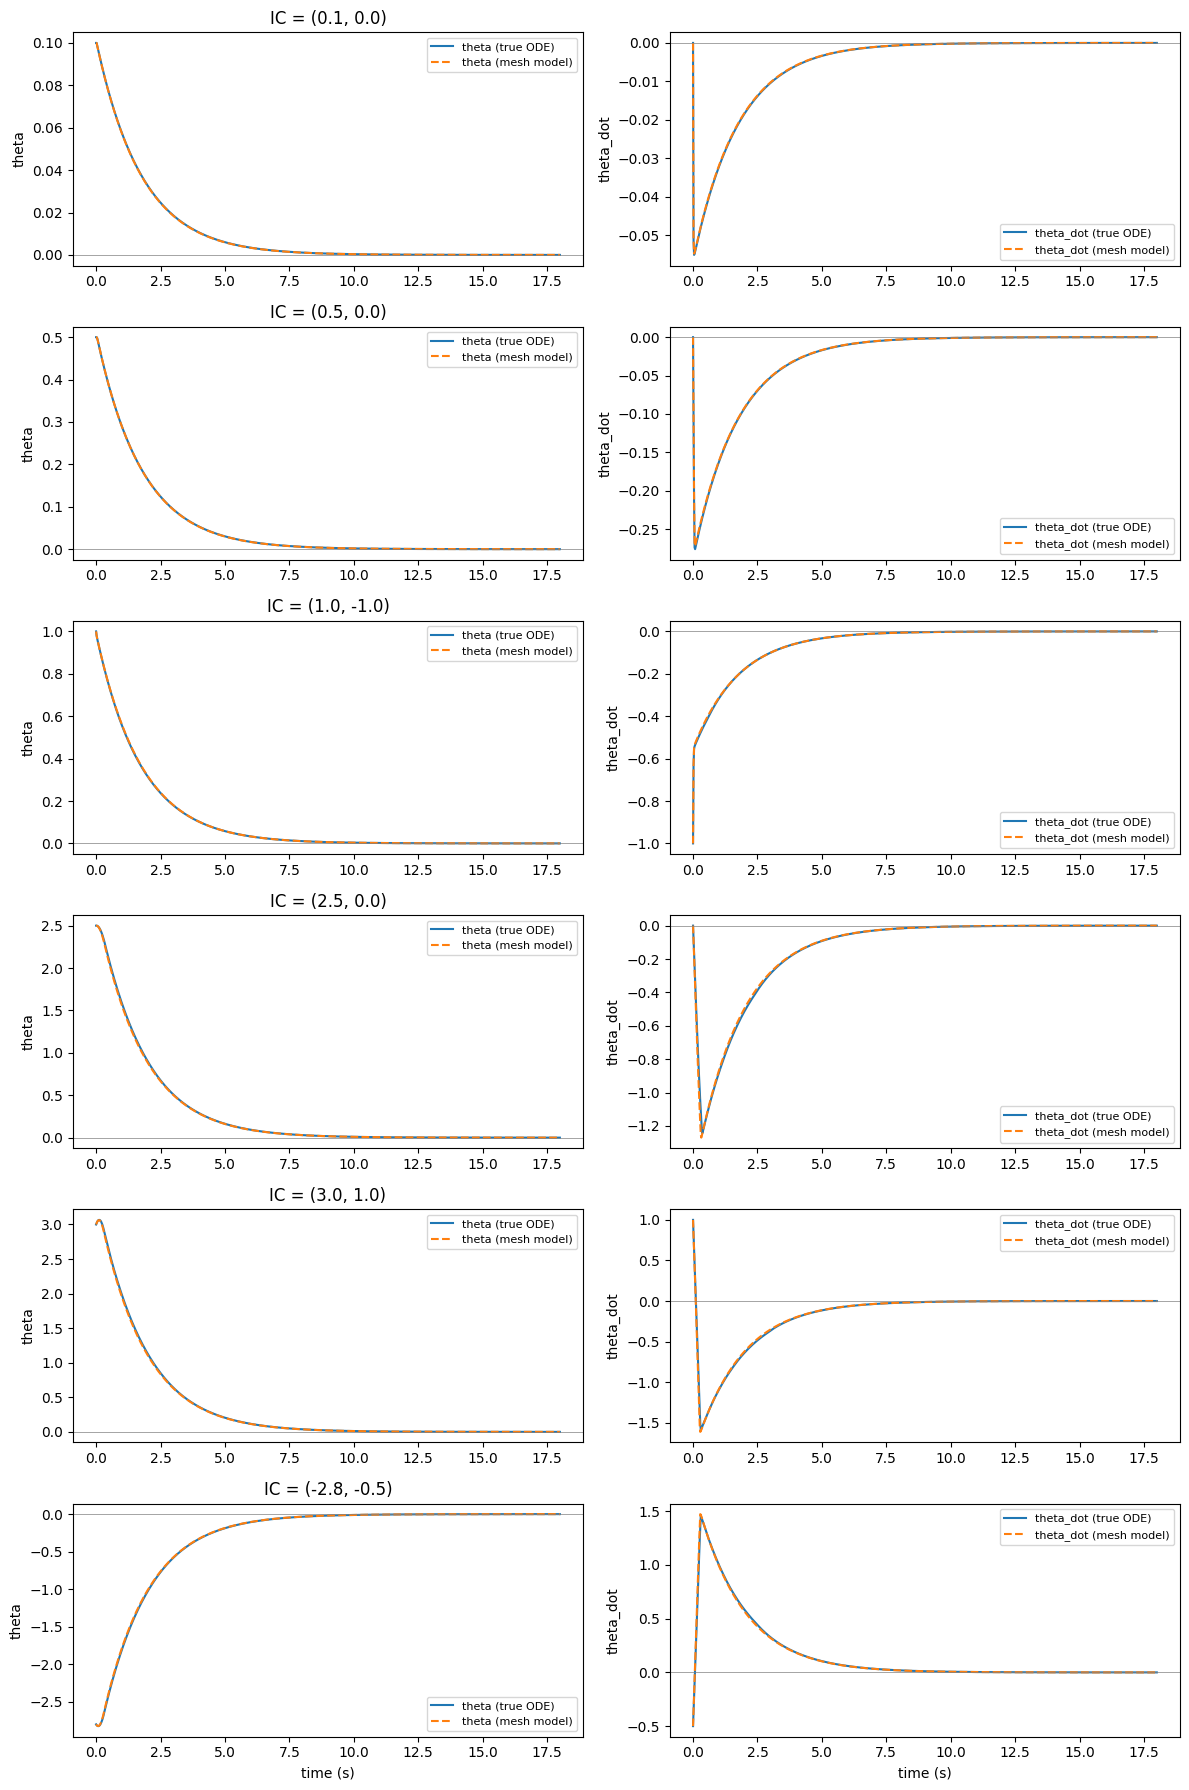


[closed-loop check] final |theta|, |theta_dot| after 18.0s, for each IC:
  IC=(0.1, 0.0): final state = [0.0000, -0.0000]  -> STABILIZED
  IC=(0.5, 0.0): final state = [0.0000, -0.0000]  -> STABILIZED
  IC=(1.0, -1.0): final state = [0.0000, -0.0000]  -> STABILIZED
  IC=(2.5, 0.0): final state = [0.0001, -0.0001]  -> STABILIZED
  IC=(3.0, 1.0): final state = [0.0001, -0.0001]  -> STABILIZED
  IC=(-2.8, -0.5): final state = [-0.0001, 0.0001]  -> STABILIZED


In [ ]:
# Closed-Loop Simulation with PDC gains

# PDC control law (same premise/weighting as the plant model):
#   u_k = - sum_i w_i(x_k) F_i x_k

if Fs is None:
    print("LMI was infeasible; Skipping closed-loop simulation")
else:
    def pdc_control(model, state, Fs, u_clip=None):
        w = mesh_weights(model, state)               # (r,)
        u = -sum(w[i] * (Fs[i] @ state) for i in range(len(w)))
        u = float(np.atleast_1d(u)[0])
        if u_clip is not None:
            u = np.clip(u, -u_clip, u_clip)
        return u

    # Running on the Neural Mesh model itself (self-consistency check)
    def simulate_true(state0, n_steps, Fs, u_clip=10.0):
        state = np.array(state0, dtype=float)
        traj = [state.copy()]
        for _ in range(n_steps):
            u = pdc_control(model, state, Fs, u_clip=u_clip)
            state = state + dt * pendulum_dynamics(state, u)
            traj.append(state.copy())
        return np.array(traj)
    # Running on the true nonlinear pendulum ODE (does the controller actually work on the system)
    def simulate_mesh(state0, n_steps, Fs, u_clip=10.0):
        state = np.array(state0, dtype=float)
        traj = [state.copy()]
        with torch.no_grad():
            for _ in range(n_steps):
                u = pdc_control(model, state, Fs, u_clip=u_clip)
                state_t = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
                u_t = torch.tensor([u], dtype=torch.float32, device=device).unsqueeze(0)
                state = model(state_t, u_t).cpu().numpy().squeeze()
                traj.append(state.copy())
        return np.array(traj)

    # Initial conditions: near equilibrium, moderate, and large-angle
    initial_conditions = [
        (0.1, 0.0),
        (0.5, 0.0),
        (1.0, -1.0),
        (2.5, 0.0),      # large angle
        (3.0, 1.0),      # near boundary of trained domain
        (-2.8, -0.5),
    ]
    n_steps = 900  # 18 seconds at dt=0.02

    fig, axs = plt.subplots(len(initial_conditions), 2, figsize=(12, 3 * len(initial_conditions)))
    for row, ic in enumerate(initial_conditions):
        traj_true = simulate_true(ic, n_steps, Fs)
        traj_mesh = simulate_mesh(ic, n_steps, Fs)
        t = np.arange(n_steps + 1) * dt

        axs[row, 0].plot(t, traj_true[:, 0], label="theta (true ODE)")
        axs[row, 0].plot(t, traj_mesh[:, 0], '--', label="theta (mesh model)")
        axs[row, 0].axhline(0.0, color='gray', linewidth=0.5)
        axs[row, 0].set_title(f"IC = {ic}")
        axs[row, 0].set_ylabel("theta")
        axs[row, 0].legend(fontsize=8)

        axs[row, 1].plot(t, traj_true[:, 1], label="theta_dot (true ODE)")
        axs[row, 1].plot(t, traj_mesh[:, 1], '--', label="theta_dot (mesh model)")
        axs[row, 1].axhline(0.0, color='gray', linewidth=0.5)
        axs[row, 1].set_ylabel("theta_dot")
        axs[row, 1].legend(fontsize=8)

    axs[-1, 0].set_xlabel("time (s)")
    axs[-1, 1].set_xlabel("time (s)")
    plt.tight_layout()
    plt.savefig("closed_loop_pdc_simulation.png", dpi=150)
    plt.show()

    # Quantitative check: Convergence of trajectory near origin
    print("\n[closed-loop check] final |theta|, |theta_dot| after "
          f"{n_steps*dt:.1f}s, for each IC:")
    for ic in initial_conditions:
        traj_true = simulate_true(ic, n_steps, Fs)
        final = traj_true[-1]
        status = "STABILIZED" if np.linalg.norm(final) < 0.05 else "DID NOT settle"
        print(f"  IC={ic}: final state = [{final[0]:.4f}, {final[1]:.4f}]  -> {status}")